In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
from pathlib import Path

EXCEL_PATH = Path("/content/drive/MyDrive/CHE44727_dataset_reframed.xlsx")
SHEET_NAME = "Sklearn_Ready"

FEATURE_COLS = [
    "Tinf_K",
    "h_conv_W_m2K",
    "rho_ice_kg_m3",
    "Cp_ice_J_kgK",
    "dH_melt_eff_J_kg",
]

TARGET_COLS = [
    "t_melt_onset_s",
    "t_noticeable_melt_s",
    "t_noticeable_soggy_s",
    "t_unacceptably_soggy_s",
    "t_finish_s",
]

In [9]:
import os

print(EXCEL_PATH)
print(EXCEL_PATH.exists())
!ls -l /content/drive/MyDrive | head
!file /content/drive/MyDrive/CHE44727_dataset_reframed.xlsx

/content/drive/MyDrive/CHE44727_dataset_reframed.xlsx
True
total 1921
-rw------- 1 root root 101618 May  3  2024 105B calculator.xlsx
-rw------- 1 root root    171 Nov  9  2023 11 1 23 WP3 Intro Notes.gdoc
drwx------ 2 root root   4096 Sep 24  2025 444B Lab
-rw------- 1 root root  10911 Jan 24  2025 Accounting of Loan 12735.xlsx
-rw------- 1 root root    171 Jan 28  2025 AMST 230 Quotes.gdoc
-rw------- 1 root root    171 Nov 19  2024 ANTH 140 Media Extra Credit.gdoc
drwx------ 2 root root   4096 Oct 21  2024 CHE 330
-rw------- 1 root root    171 Mar 31  2025 CHE 350 AVEVA Project #1.gdoc
drwx------ 2 root root   4096 Apr 13 21:02 CHE 442 Materials
/content/drive/MyDrive/CHE44727_dataset_reframed.xlsx: Microsoft Excel 2007+


In [10]:
df = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME, header=2)

needed_cols = FEATURE_COLS + TARGET_COLS
print(df.columns.tolist())

df_model = df.dropna(subset=needed_cols).copy()

X = df_model[FEATURE_COLS]
y = df_model[TARGET_COLS]


['case_id', 'Tinf_K', 'h_conv_W_m2K', 'rho_ice_kg_m3', 'Cp_ice_J_kgK', 'dH_melt_eff_J_kg', 'first_visible_drip_exp_s', 't_melt_onset_s', 't_noticeable_melt_s', 't_noticeable_soggy_s', 't_unacceptably_soggy_s', 't_finish_s', 'M_melt_1800_g', 'M_abs_1800_g']


In [11]:
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(
        n_estimators=300,
        max_depth=4,
        random_state=42
    ))
])

loo = LeaveOneOut()
y_pred = cross_val_predict(model, X, y, cv=loo)
pred_df = pd.DataFrame(y_pred, columns=[f"pred_{c}" for c in TARGET_COLS], index=df_model.index)

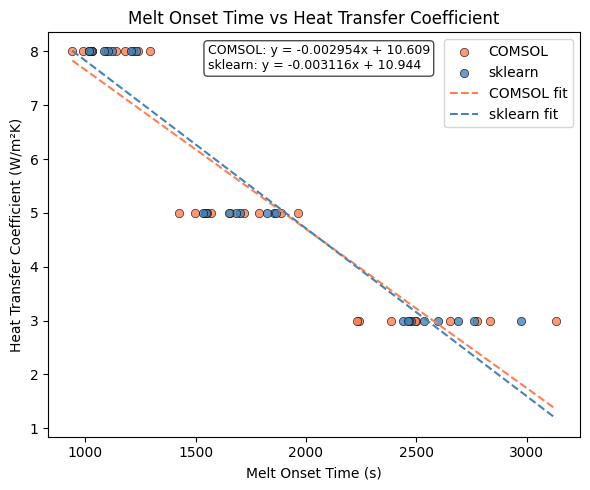

In [52]:
h = df_model["h_conv_W_m2K"].values
actual = df_model["t_melt_onset_s"].values
predicted = pred_df["pred_t_melt_onset_s"].values

m_act,  b_act  = np.polyfit(actual,    h, 1)
m_pred, b_pred = np.polyfit(predicted, h, 1)

x_line = np.linspace(min(actual.min(), predicted.min()),
                     max(actual.max(), predicted.max()), 200)

plt.figure(figsize=(6, 5))

# Scatterplot of predicted and actual data points
plt.scatter(actual,h,label="COMSOL", color="coral",edgecolors="k",linewidths=0.5,alpha=0.8)
plt.scatter(predicted,h,label="sklearn", color="steelblue",edgecolors="k",linewidths=0.5, alpha=0.8)

# Regression lines
plt.plot(x_line,m_act*x_line+b_act,color="coral",linewidth=1.5,linestyle="--",label="COMSOL fit")
plt.plot(x_line,m_pred*x_line+b_pred,color="steelblue",linewidth=1.5,linestyle="--",label="sklearn fit")

# Equation labels
eq_actual = f"COMSOL: y = {m_act:.6f}x + {abs(b_act):.3f}"
eq_pred   = f"sklearn: y = {m_pred:.6f}x + {abs(b_pred):.3f}"

plt.text(
    0.30, 0.97,
    f"{eq_actual}\n{eq_pred}",
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)

plt.xlabel("Melt Onset Time (s)")
plt.ylabel("Heat Transfer Coefficient (W/m²K)")
plt.title("Melt Onset Time vs Heat Transfer Coefficient")
plt.legend()
plt.tight_layout()
plt.show()

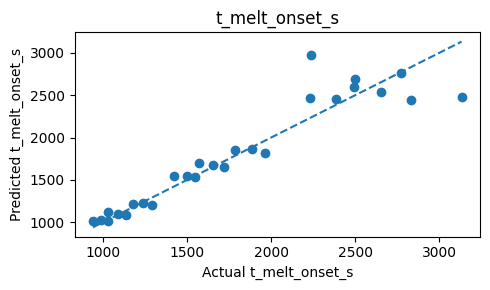

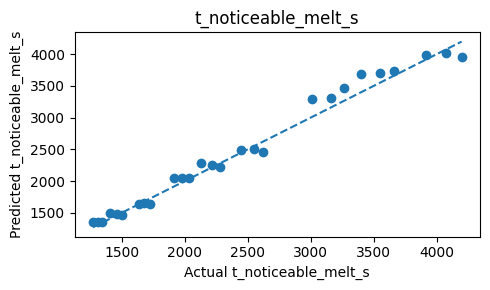

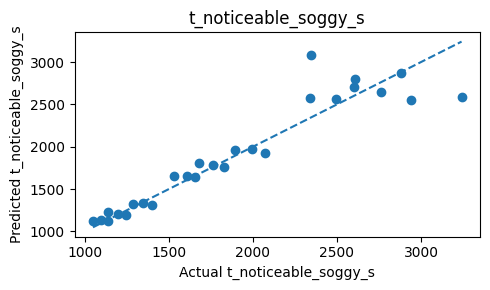

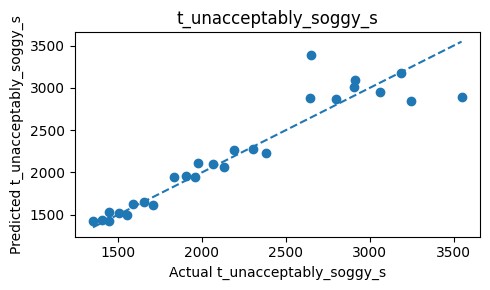

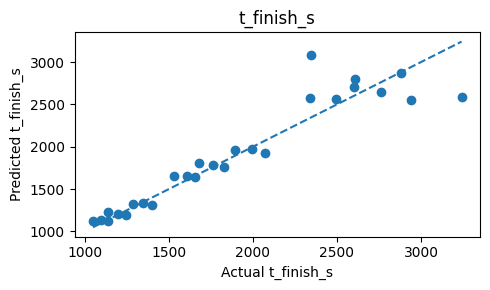

In [36]:
for i, target in enumerate(TARGET_COLS):
    actual = y.iloc[:, i].values
    pred = y_pred[:, i]

    plt.figure(figsize=(5, 3))
    plt.scatter(actual, pred)
    lo = min(actual.min(), pred.min())
    hi = max(actual.max(), pred.max())
    plt.plot([lo, hi], [lo, hi], linestyle="--")
    plt.xlabel(f"Actual {target}")
    plt.ylabel(f"Predicted {target}")
    plt.title(target)
    plt.tight_layout()
    plt.show()

In [13]:
model.fit(X, y)

rf = model.named_steps["rf"]
importance_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

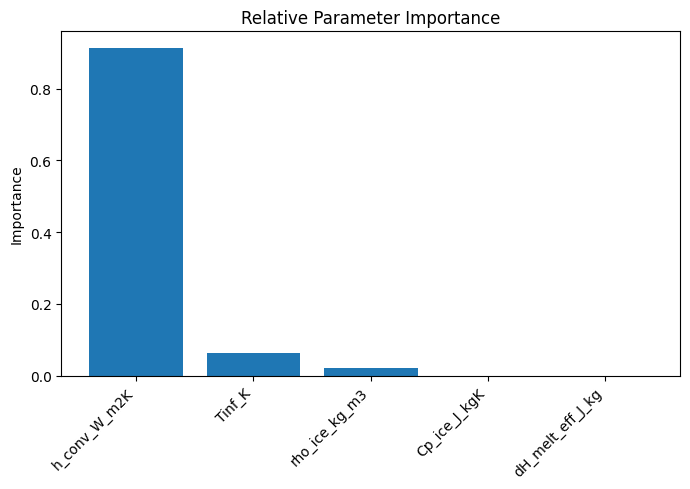

In [56]:
plt.figure(figsize=(7, 5))
plt.bar(importance_df["feature"], importance_df["importance"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("Relative Parameter Importance")
plt.tight_layout()
plt.show()